In [51]:
from pandas import DataFrame,read_csv
from numpy import nan
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score,f1_score,recall_score,precision_score,roc_auc_score,ConfusionMatrixDisplay,RocCurveDisplay)

import joblib


In [2]:
df = read_csv("data/adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.describe(include="str")

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [8]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(24)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(32537, 15)

In [12]:
df.drop("fnlwgt",axis=1,inplace=True)

In [13]:
df.shape

(32537, 14)

income
<=50K    24698
>50K      7839
Name: count, dtype: int64
-------------------------------------------------------------------------------------
income
<=50K    75.907428
>50K     24.092572
Name: proportion, dtype: float64
-------------------------------------------------------------------------------------


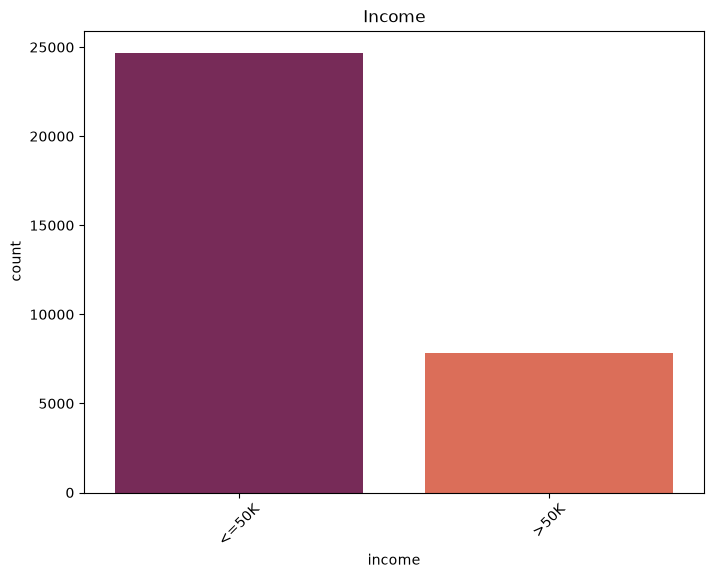

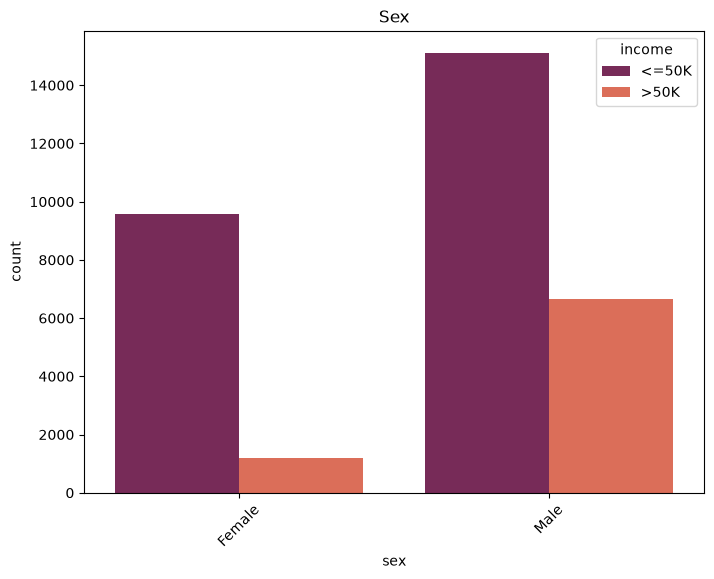

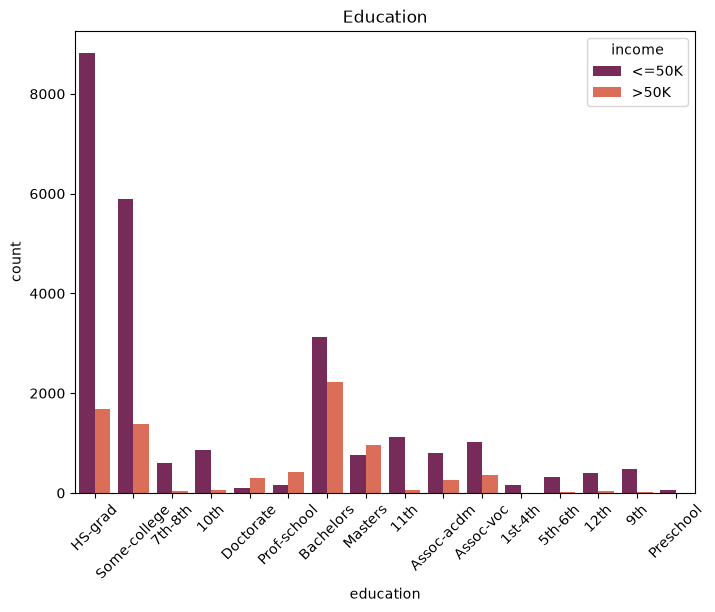

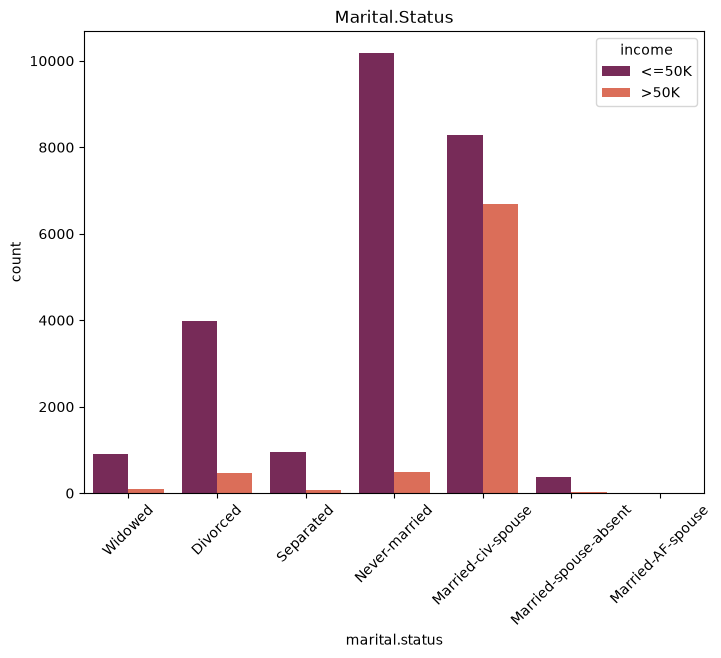

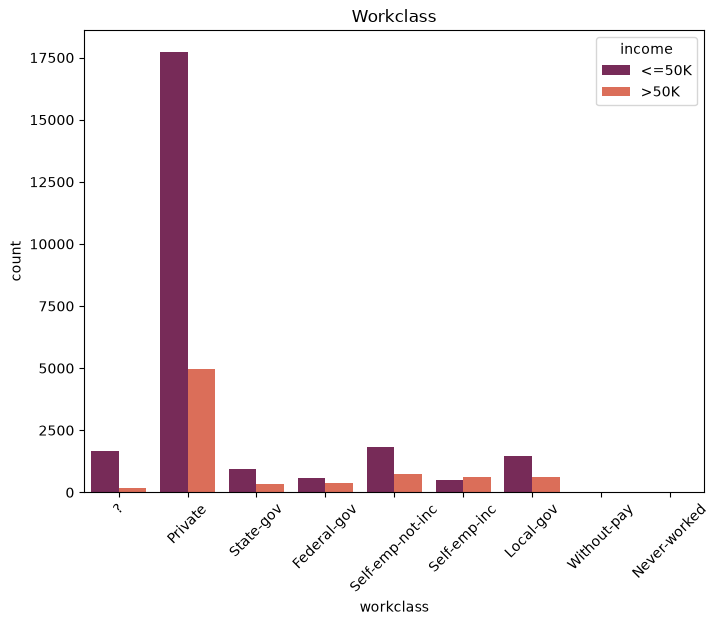

In [17]:
print(df["income"].value_counts())
print("-"*85)
print(df["income"].value_counts(normalize=True)*100)
print("-"*85)

cols= {
    "income":"Income",
    "sex":"Sex",
    "education":"Education",
    "marital.status":"Marital.Status",
    "workclass":"Workclass"
}
for col,title in cols.items():
    plt.figure(figsize=(8,6))
    sns.countplot(df,x=col,hue="income",palette="rocket")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.savefig(f"images/Countplots/{title}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()

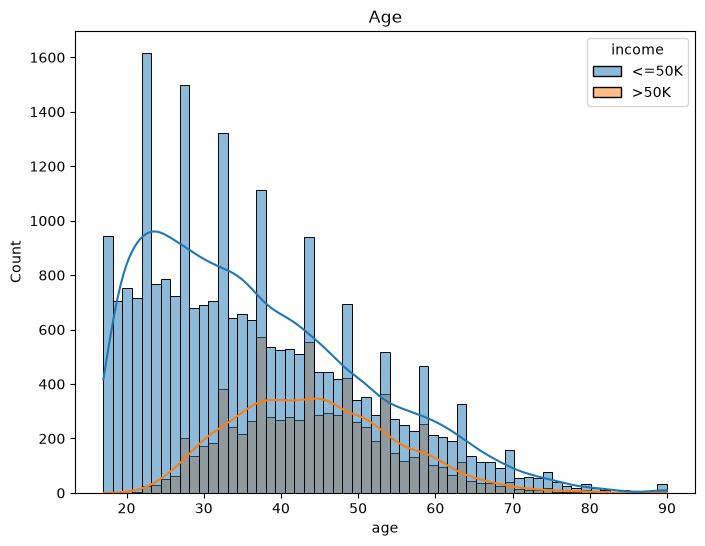

-------------------------------------------------------------------------------------


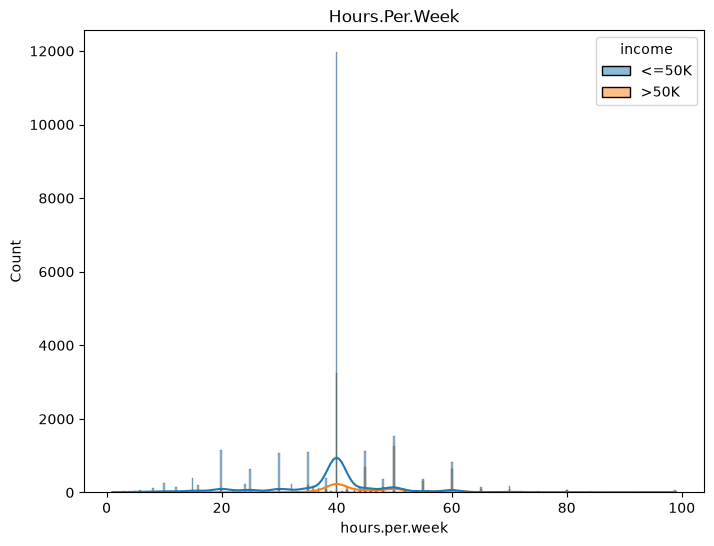

-------------------------------------------------------------------------------------


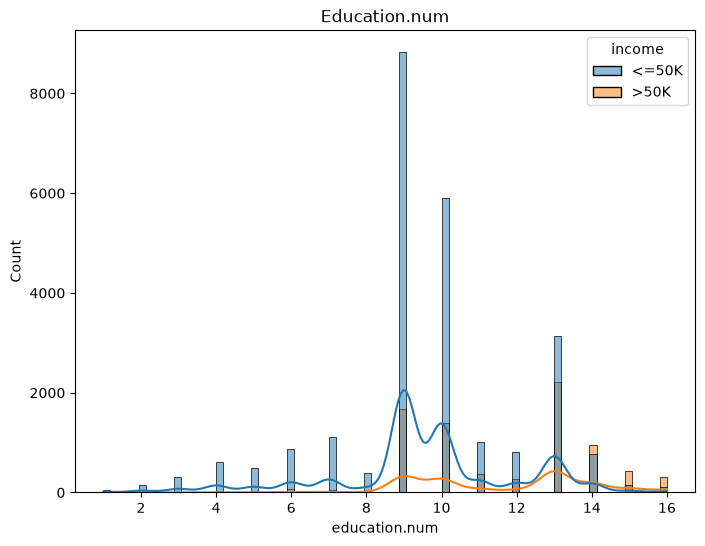

-------------------------------------------------------------------------------------


In [18]:
cols_hist = {
    "age":"Age",
    "hours.per.week":"Hours.Per.Week",
    "education.num":"Education.num"
}

for col,ti in cols_hist.items():
    plt.figure(figsize=(8,6))
    sns.histplot(df,x=col,hue="income",kde=True)
    plt.title(ti)
    plt.savefig(f"images/Histplots/{ti}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()
    print("-"*85)

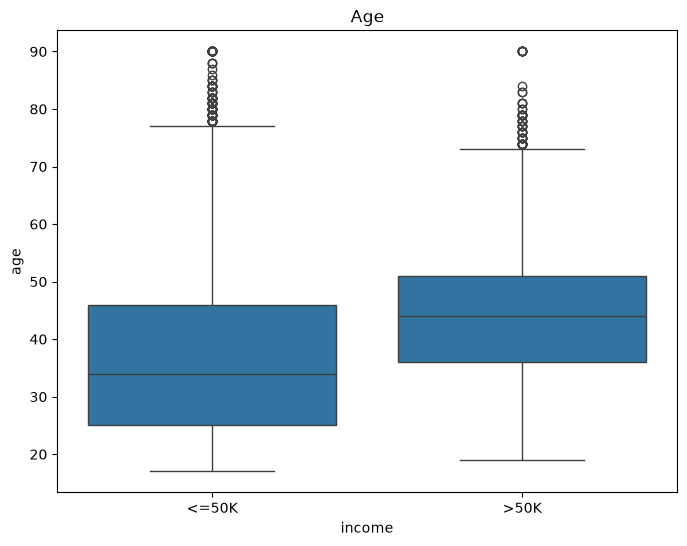

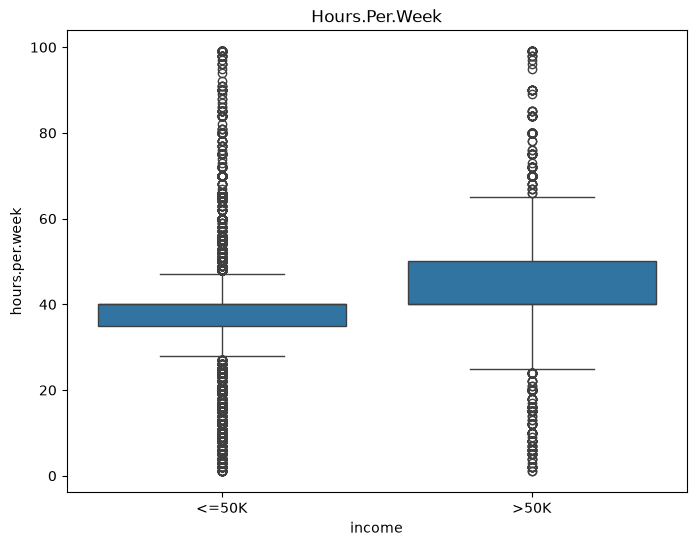

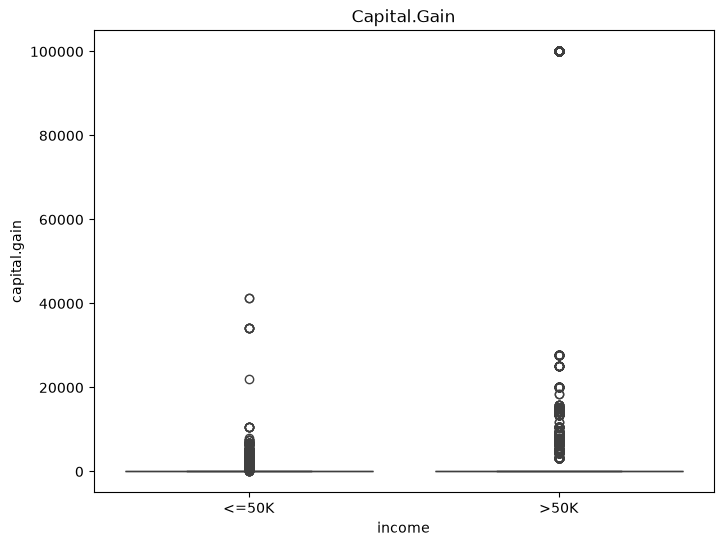

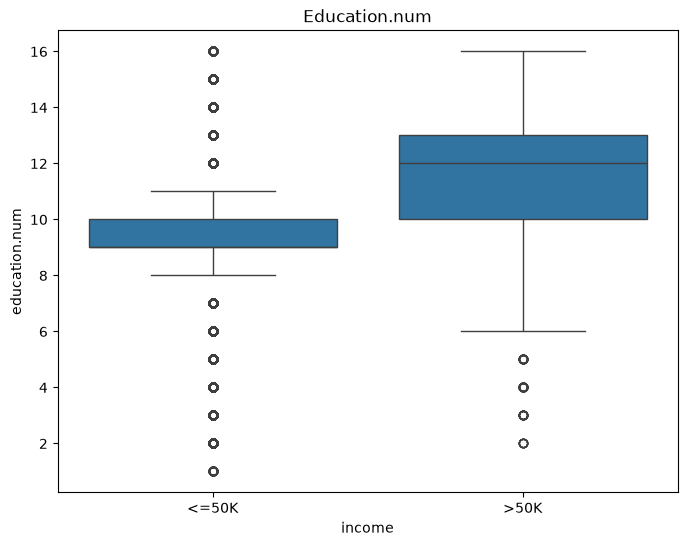

In [19]:
cols_box = {
    "age":"Age",
    "hours.per.week":"Hours.Per.Week",
    "capital.gain":"Capital.Gain",
    "education.num":"Education.num"
}

for col,ti  in cols_box.items():
    plt.figure(figsize=(8,6))
    sns.boxplot(df,x="income",y=col)
    plt.title(ti)
    plt.savefig(f"images/Boxplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()
    

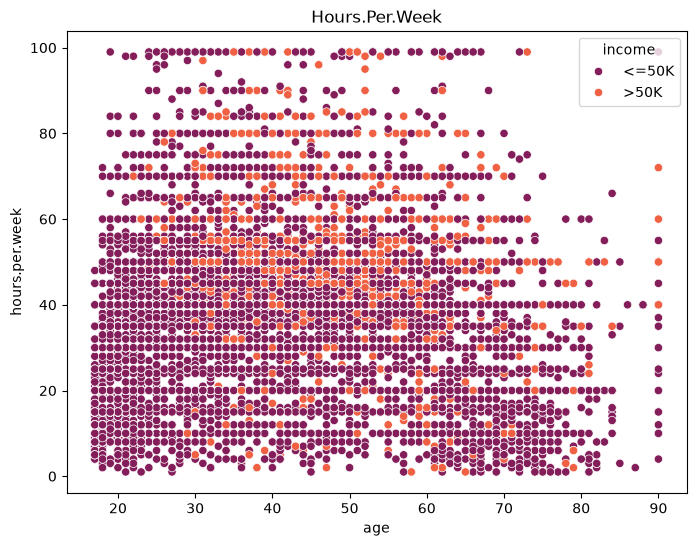

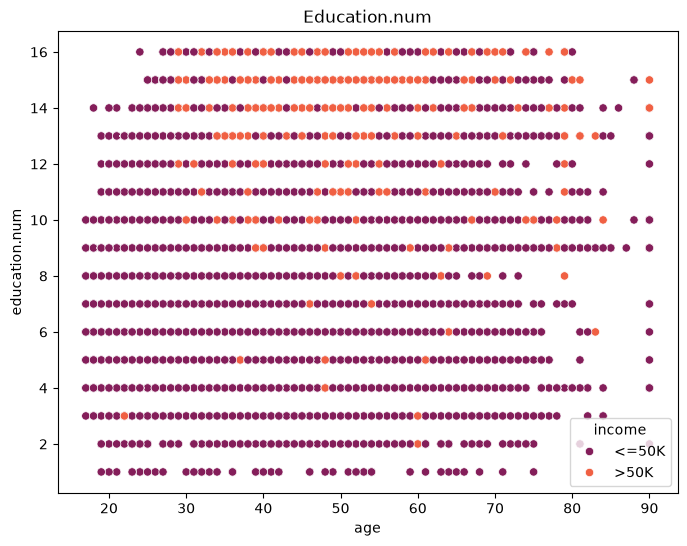

In [20]:
cols_sca = {
    "hours.per.week":"Hours.Per.Week",
    "education.num":"Education.num"
}

for col,ti in cols_sca.items():
    plt.figure(figsize=(8,6))
    sns.scatterplot(df,x='age',y=col,hue="income",palette="rocket")
    plt.title(ti)
    plt.savefig(f"images/Scatterplots/{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()
    

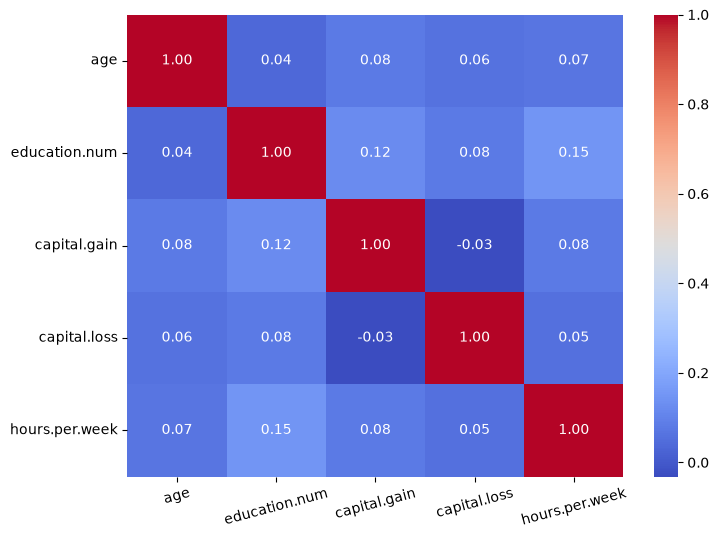

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.xticks(rotation=15)
plt.savefig(f"images/Heatmap/HeatMap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [22]:
df = df.replace("?",nan)

df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [23]:
X = df.drop("income",axis=1)
y = df["income"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
numeric_col = ["age","education.num","capital.gain","capital.loss","hours.per.week"]
cat_col = ["workclass","education","marital.status","occupation","relationship","race","sex","native.country"]

In [25]:
preprocessor = ColumnTransformer([
    ("num",SimpleImputer(strategy="median"),numeric_col),
    ("cat",Pipeline([
        ("impute",SimpleImputer(strategy="most_frequent")),
        ("encode",OneHotEncoder(handle_unknown="ignore"))
    ]),cat_col)
])

Random Forest

In [26]:
pipe_RF = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])

param_RF = {
    "model__n_estimators": [100, 200,300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [32]:
grid_RF = RandomizedSearchCV(pipe_RF,param_RF,n_iter=20,cv=5,scoring="roc_auc",n_jobs=-1,verbose=1,random_state=42)

In [33]:
grid_RF.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` 

In [34]:
print("-"*40," Random Forest ","-"*40)
print("Best Params : ",grid_RF.best_params_)
print("Best Score : ",grid_RF.best_score_)

----------------------------------------  Random Forest  ----------------------------------------
Best Params :  {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Best Score :  0.9181257968111354


XGBoost

In [35]:
pipe_XG = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBClassifier(random_state=42,eval_metric="logloss"))
])

param_XG = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}

In [36]:
grid_XG = RandomizedSearchCV(pipe_XG,param_XG,n_iter=20,cv=5,n_jobs=-1,verbose=1,scoring="roc_auc",random_state=42)

In [37]:
grid_XG.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set 

In [38]:
print("-"*40," XGBoost ","-"*40)
print("Best Params : ",grid_XG.best_params_)
print("Best Score : ",grid_XG.best_score_)

----------------------------------------  XGBoost  ----------------------------------------
Best Params :  {'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Best Score :  0.9288503784545574


LightGBM

In [39]:
pipe_LGBM = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LGBMClassifier(random_state=42,verbosity=-1,n_jobs=1))
])

param_LGBM = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [-1, 5, 10],
    "model__num_leaves": [15, 31, 63],
    "model__min_child_samples": [10, 20, 30],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0, 0.1, 1]
}

In [40]:
grid_LGBM = RandomizedSearchCV(pipe_LGBM,param_LGBM,n_iter=20,cv=5,n_jobs=1,verbose=1,scoring="roc_auc",random_state=42)

In [41]:
grid_LGBM.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 5, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` c

In [42]:
print("-"*40," LightGBM ","-"*40)
print("Best Params : ",grid_LGBM.best_params_)
print("Best Score : ",grid_LGBM.best_score_)

----------------------------------------  LightGBM  ----------------------------------------
Best Params :  {'model__subsample': 0.8, 'model__reg_lambda': 0, 'model__reg_alpha': 0.1, 'model__num_leaves': 15, 'model__n_estimators': 200, 'model__min_child_samples': 10, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best Score :  0.9293163964131897


Gradient Boosting

In [43]:
pipe_GB = Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingClassifier(random_state=42))
])

param_GB = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0]
}

In [44]:
grid_GB = RandomizedSearchCV(pipe_GB,param_GB,n_iter=20,cv=5,scoring="roc_auc",n_jobs=-1,verbose=1,random_state=42)

In [45]:
grid_GB.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` ca

In [46]:
print("-"*40," Gradient Boosting ","-"*40)
print("Best Params : ",grid_GB.best_params_)
print("Best Score : ",grid_GB.best_score_)

----------------------------------------  Gradient Boosting  ----------------------------------------
Best Params :  {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Best Score :  0.9287650717823223


In [47]:
Models = {
    "Random_Forest":grid_RF.best_estimator_,
    "XGBoost":grid_XG.best_estimator_,
    "LightGBM":grid_LGBM.best_estimator_,
    "Gradien_Boosting":grid_GB.best_estimator_
}

In [48]:
results = []

for name, model in Models.items():

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred)*100,
        "Precision": precision_score(y_test, y_pred)*100,
        "Recall": recall_score(y_test, y_pred)*100,
        "F1": f1_score(y_test, y_pred)*100,
        "ROC-AUC": roc_auc_score(y_test, y_prob)*100
    })

In [49]:
res_df = DataFrame(results,index=["",'','',''])
res_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
,Random_Forest,86.293792,75.039872,61.907895,67.844268,91.645034
,XGBoost,87.323294,76.069017,66.710526,71.083070,92.649820
,LightGBM,87.430854,76.712329,66.315789,71.136203,92.737089
,Gradien_Boosting,87.277197,76.371951,65.921053,70.762712,92.608154


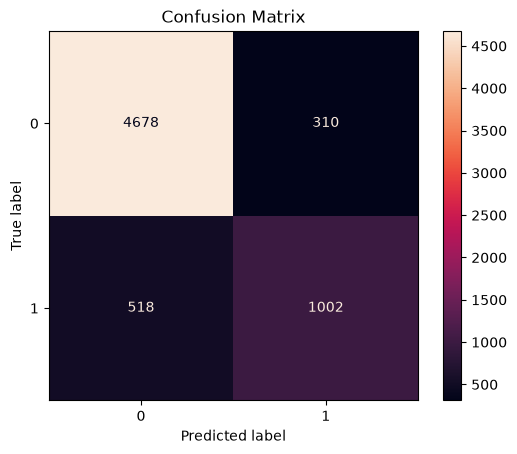

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="rocket")
plt.title("Confusion Matrix")
plt.savefig(f"images/Cunfusion_matrix/confusion-matrix.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [52]:
joblib.dump(grid_RF.best_estimator_,"models/RandomForest_Model.joblib")
joblib.dump(grid_XG.best_estimator_,"models/XGBoost_Model.joblib")
joblib.dump(grid_LGBM.best_estimator_,"models/LightGBM_Model.joblib")
joblib.dump(grid_GB.best_estimator_,"models/GradientBoosting_Model.joblib")
print("Models Saved")

Models Saved
